# https://docs.os.uk/os-downloads/products/water-portfolio/os-open-rivers

In [ ]:
import geopandas as gpd
import numpy as np
import contextily as ctx
import matplotlib.pyplot as plt

rivers_route_file = "../data/oprvrs_gpkg_gb/Data/oprvrs_gb.gpkg"

counties_file = "../data/bdline_gpkg_gb/Data/bdline_gb.gpkg"

In [2]:
# Load the county boundaries
high_water = gpd.read_file(counties_file, layer="high_water")

counties = gpd.read_file(counties_file, layer="boundary_line_historic_counties")

display(gpd.list_layers(counties_file))

,name,geometry_type
0,boundary_line_ceremonial_counties,MultiPolygon
1,boundary_line_historic_counties,MultiPolygon
2,community_ward,MultiPolygon
3,country_region,MultiPolygon
4,county,MultiPolygon
5,county_electoral_division,MultiPolygon
6,district_borough_unitary,MultiPolygon
7,district_borough_unitary_ward,MultiPolygon
8,english_region,MultiPolygon
9,greater_london_const,MultiPolygon


In [3]:
display(gpd.list_layers(rivers_route_file))

nodes = gpd.read_file(rivers_route_file, layer="hydro_node")

links = gpd.read_file(rivers_route_file, layer="watercourse_link")

,name,geometry_type
0,hydro_node,Point
1,watercourse_link,LineString


In [4]:
links

,id,flow_direction,length,fictitious,form,watercourse_name,watercourse_name_alternative,start_node,end_node,geometry
0,CBB29128-E3D9-41DC-B42D-C897B91BC798,in direction,698.0,0,inlandRiver,NaN,NaN,EEB098C2-0A0E-43CD-8412-4934607F27BC,47BE35B6-7896-40ED-BD09-1E5268B934BB,"LINESTRING (464870.89 1213066.83, 464803.34 12..."
1,A9DE91C2-3E83-4CB0-8054-A67D58B250F3,in direction,1638.0,0,inlandRiver,Burn of Skaw,NaN,EEBA1BA4-EB4F-4F7B-8F23-6F12439C0D72,6CCA1E9F-C1B5-4779-9F82-225CA799EB59,"LINESTRING (464604.98 1216285.95, 464623.92 12..."
2,2BA5B04B-0E80-435A-8FEE-BD1AE04B033B,in direction,88.0,0,inlandRiver,NaN,NaN,AB52C15B-AD0E-4241-B4F9-EC56D89BF228,BF7D6801-67F9-4361-9819-C3DF559CF72C,"LINESTRING (464702.95 1214013.85, 464663.95 12..."
3,F6B7A545-A959-488C-8145-1ED951A40FF7,in direction,559.0,0,inlandRiver,Burn of Norwick,NaN,BF7D6801-67F9-4361-9819-C3DF559CF72C,4E41746F-D1E3-4D1C-B2EC-85177FDDD967,"LINESTRING (464632.76 1214060.7, 464657.26 121..."
4,8EC680EF-3C36-4C57-946F-7868FC06A035,in direction,96.0,0,inlandRiver,NaN,NaN,A23D8A47-32E5-499A-8820-EEE2716F4D13,4E41746F-D1E3-4D1C-B2EC-85177FDDD967,"LINESTRING (464782.25 1214486.58, 464876.25 12..."
...,...,...,...,...,...,...,...,...,...,...
193035,5CEB28DA-2FB6-430B-9ECC-136EC390B18B,in direction,232.0,0,inlandRiver,NaN,NaN,350FB812-C546-45EF-AB20-750F59F5A5FF,46FF6485-71DA-468D-97E3-27E0740BE5B8,"LINESTRING (142067.43 33538.46, 142050.77 3352..."
193036,DB7D9A1C-2451-4E3C-AA6A-88DAFD69F02E,in direction,732.0,0,inlandRiver,NaN,NaN,6707A242-4329-44E0-9E7C-B4507A80B796,9B3545A0-5385-4A55-9951-FF35DAB13C3C,"LINESTRING (145424.72 35748.27, 145428.69 3571..."
193037,540E6D0B-36A4-4E5C-BF7B-B64B94113F7D,in direction,568.0,0,inlandRiver,NaN,NaN,9F8D5AA3-6A1C-4E6F-A11A-DF2A23EFAA02,4844ACBC-A80F-4E3E-B356-3406EBDFDA76,"LINESTRING (139378.67 35449.55, 139335.43 3551..."
193038,85AE135D-AF25-4F52-86B0-D52916F62FF2,in direction,733.0,0,inlandRiver,NaN,NaN,BB1A5624-43FB-405C-91C6-37FFBADBF7A0,48331820-E0B0-4B85-B626-BAD6A8FDBA65,"LINESTRING (143070.37 37026.09, 143047.38 3703..."


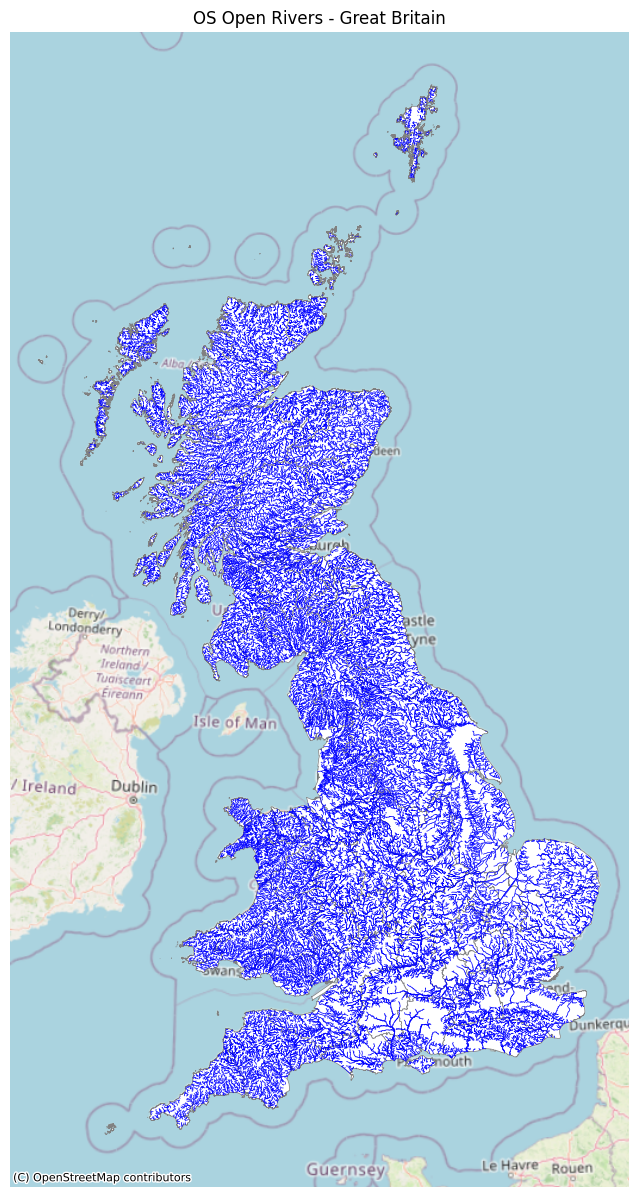

In [10]:
fig, ax = plt.subplots(figsize=(10, 15))

counties.plot(ax=ax, linewidth=0.5, color='white', edgecolor='grey')
links.plot(ax=ax, linewidth=0.5, color='blue')

ctx.add_basemap(ax, crs=counties.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

# Clean up the plot
ax.set_title("OS Open Rivers - Great Britain")
ax.set_axis_off()
plt.show()

KeyboardInterrupt: 

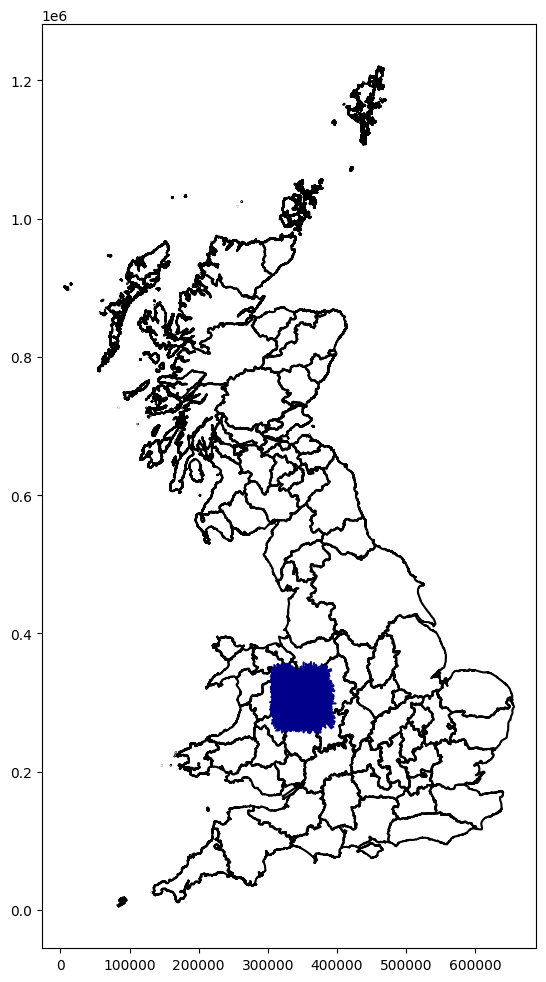

In [ ]:
import numpy as np
import contextily as ctx

# Find Shropshire in the counties GeoDataFrame (checking common column names)
if 'name' in counties.columns:
    shropshire = counties[counties['name'].str.contains('Shropshire', case=False, na=False)]
elif 'NAME' in counties.columns:
    shropshire = counties[counties['NAME'].str.contains('Shropshire', case=False, na=False)]
else:
    # Fallback to visual inspection of columns if needed
    shropshire = counties[counties.iloc[:, 0].astype(str).str.contains('Shropshire', case=False, na=False)]

fig, ax = plt.subplots(figsize=(12, 12))

# Get the bounding box of Shropshire to set extent
minx, miny, maxx, maxy = shropshire.total_bounds

# Filter rivers within the bounding box
shropshire_rivers = links.cx[minx:maxx, miny:maxy]

# Plot counties and rivers
# Swapped color='white' to facecolor='none' so the basemap is visible underneath
counties.plot(ax=ax, linewidth=1.5, facecolor='none', edgecolor='black')
shropshire_rivers.plot(ax=ax, linewidth=1.5, color='blue')

# Add flow direction arrows
# Using line direction (first coord -> last coord or midway angle)
for idx, row in shropshire_rivers.iterrows():
    line = row.geometry
    if line.geom_type == 'LineString':
        coords = list(line.coords)
        if len(coords) >= 2:
            # Find the midpoint index
            mid = len(coords) // 2
            p1 = coords[mid-1]
            p2 = coords[mid]
            
            # Calculate the direction
            dx = p2[0] - p1[0]
            dy = p2[1] - p1[1]
            
            # Normalize arrows manually
            length = np.hypot(dx, dy)
            if length > 0:
                ax.annotate(
                    '', xy=(p2[0], p2[1]), xytext=(p1[0], p1[1]),
                    arrowprops=dict(arrowstyle="->", color="darkblue", lw=1.5)
                )
    elif line.geom_type == 'MultiLineString':
        # Handle MultilineStrings if they exist
        for prt in line.geoms:
            coords = list(prt.coords)
            if len(coords) >= 2:
                mid = len(coords) // 2
                p1 = coords[mid-1]
                p2 = coords[mid]
                ax.annotate(
                    '', xy=(p2[0], p2[1]), xytext=(p1[0], p1[1]),
                    arrowprops=dict(arrowstyle="->", color="darkblue", lw=1.5)
                )

# Set limits to zoom in BEFORE adding basemap to avoid fetching tiles for the whole country
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Add OSM basemap
ctx.add_basemap(ax, crs=counties.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik, zoom=11)

ax.set_title("OS Open Rivers - Shropshire with Flow Direction and OSM Basemap")
ax.set_axis_off()
plt.show()